# 09. your own analysis

### CAJAL Neuromics Summer School, Bordeaux 2026 · a spatial metabolomics primer

This is the last notebook, and it is almost empty on purpose. The ones before it walked
you down a fixed path: load the raw METASPACE ions, annotate them, normalize with uMAIA,
embed, cluster into your own lipizones, and test which lipids change in pregnancy. Every
step was scaffolded. You ran code whose insides you had already seen unrolled.

Now the scaffold comes off. You pick a question, you choose the tools, you run the analysis,
and you defend the result. That is what doing science actually feels like, and it is the
single most useful thing you can practice this week. A working pipeline is not the goal.
A good question, answered honestly, is.

You will not be alone. You have the `cajal_lipidomics` helpers, you have the data you built
yourself stage by stage, you have the finished notebooks as a reference library, and you
have Claude Code next to you to write code on demand. The skill this notebook trains is not
typing. It is steering: deciding what to ask, judging what comes back, and noticing when
something is wrong.

## the callouts, one last time

- 🔬 **TASK**: something you do (write or run code).
- 💡 **HINT**: a nudge when you are stuck.
- ❓ **QUESTION**: pause and think, no code required.
- **check:** what you should see if it worked. If your screen disagrees, stop and fix it.

🔬 **TASK.** Run the next cell to load the stack and the data. You have run this exact
header in every notebook, so it should feel routine by now.

In [1]:
# the scientific-Python stack, the course helpers, the data you built
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import anndata as ad
import cajal_lipidomics as cl
from cajal_lipidomics import analysis, plotting, embedding, multimodal, annotation
from cajal_lipidomics.style import set_style
set_style()  # the course-wide figure look: clean axes, vector text, fixed font sizes

# one global seed so every number and figure below is reproducible
SEED = 0
np.random.seed(SEED)

# load the LAST stage you produced: 06_clustered.h5ad, the end of the chain you built
# (01_raw -> 02_annotated -> 03_normalized -> 05_embedded -> 06_clustered). this is YOUR
# result, not a pre-baked answer file. it carries the raw ions, the uMAIA-normalized values
# in a layer, the NMF/Harmony/t-SNE embeddings, and your OWN lipizone labels.
adata = ad.read_h5ad("../../data/derived/06_clustered.h5ad")

# make it analysis-ready: put the uMAIA-normalized intensities in X, and name the columns by
# the lipid each ion was annotated to (the helpers look lipids up by var_names). some ions are
# isobaric or share an adduct, so a few names repeat, and ~40 ions stayed unannotated ('ion_...').
adata.X = np.asarray(adata.layers["umaia"])
adata.var_names = pd.Index(adata.var["lipid"].astype(str))

print(f"loaded {adata.n_obs} pixels x {adata.n_vars} ions "
      f"({int((~adata.var['lipid'].str.startswith('ion_')).sum())} annotated to a lipid name)")
print("conditions:", adata.obs["Condition"].value_counts().to_dict())
print("your own lipizones:", adata.obs["lipizone"].nunique())

loaded 189011 pixels x 104 ions (63 annotated to a lipid name)
conditions: {'pregnant': 100258, 'naive': 88753}
your own lipizones: 26


**check:** you should see about `189011 pixels x 104 ions`, the two conditions `naive`
(control) and `pregnant` with roughly 89k and 100k pixels, and your own set of lipizones
(around 26, give or take, depending on the resolution you clustered at). No red error. If you
get a `FileNotFoundError`, check the relative path to `data/derived/06_clustered.h5ad` from
wherever this notebook lives. If that file does not exist yet, go back and run the clustering
notebook that produces it: this notebook deliberately builds on the chain you made, not on any
answer file.

## what you already know how to do

Before you invent something new, take stock of the machine you have built. Here is the whole
pipeline in one place, each step paired with the helper that performs it. Treat this as your
menu. Almost any project you propose will be a recombination of these pieces.

**The data.** `adata.X` is now the uMAIA-normalized intensity, one row per pixel, one column
per ion (`adata.var_names`, named by the lipid we annotated each ion to). A pixel is one MALDI
laser spot, roughly 25 micrometres, not one cell: it mixes cell bodies, axons, dendrites, and
glia. `adata.obs` carries the metadata you will lean on most: `Condition` (naive vs pregnant),
`SectionID`, the Allen atlas region `acronym` (with its colour `allencolor`), your own cluster
labels in `lipizone`, and the spatial coordinates `x`, `y`, `zccf`, `yccf`, `xccf`. The
embeddings live in `adata.obsm`: `X_nmf` (the parts-based lipid programs), `X_harmony` (the
same, batch-corrected for clustering), and `X_tsne` (the 2-D map for the eye).

**Look at the data in space.** `plotting.spatial_lipid(adata, "PA 34:1")` paints one lipid on
the tissue across both sections with a shared colour scale. `plotting.spatial_categorical(adata,
color_key="allencolor")` paints the pixels by Allen region. Looking first is not optional, it is
the teaching.

**Annotate a peak.** A MALDI measurement is a mass, not a name. `annotation.match_lcms` and
`annotation.plot_ppm_match` match an observed m/z to a reference lipid within a parts-per-million
window, and draw the match so you can see why it holds. This is how the `ion_...` columns would
get names if you pushed the annotation further.

**Embed and cluster.** `embedding.seeded_nmf(adata.X)` factors the lipids into a handful of
non-negative, additive programs (the parts-based recipe). `embedding.harmonize` removes the
section-to-section batch offset in that program space, but only for clustering and label
transfer, never for the statistics. `embedding.leiden_clusters` cuts the neighbour graph into
communities, the data-driven territories we call lipizones. The paper discovers its lipizones
with a divisive top-down binary splitter rather than Leiden, so treat your Leiden communities as a
transparent, single-resolution stand-in for that hierarchy, not a reproduction of it.

**Transfer labels.** `embedding.knn_transfer` copies cluster labels from the control brain onto
the pregnant brain through the shared, harmonized embedding, so the two conditions speak the same
anatomical language. Your `lipizone` column was built exactly this way. The paper transfers labels
with a different mechanism, the per-node XGBoost classifier of its splitting tree, so again this is
the course's simpler kNN stand-in for the same idea: annotate new pixels from a labelled reference.

**Test what changes.** `analysis.differential_lipids(adata, "Condition", "naive", "pregnant")`
runs a Wilcoxon rank-sum test per lipid with a Benjamini-Hochberg correction, returning a log2
fold change, a corrected q-value, and a significance flag. `plotting.volcano` draws it.
`analysis.marker_lipids` finds the lipids that define each cluster.

**Score and interpret.** `analysis.myelination_score` averages the z-scored sphingolipids
(`HexCer`, `Cer`, `SM`) per pixel as a myelin proxy. `analysis.morans_i` measures whether a
feature is spatially structured or salt-and-pepper noise. `multimodal.region_change_matrix`
builds the per-region pregnancy change, and the rest of `multimodal` (gene programs, XGBoost
prediction, SHAP) asks which genes track which lipid changes, using the MERFISH table in
`data/merfish_plane.parquet`.

That is the toolbox. Now we use a sliver of it on one tiny question, end to end, as a model for
your own.

💡 **HINT.** Every helper named above is a short, readable file in `src/cajal_lipidomics/`, grouped by the module it sits in: `analysis.py`, `plotting.py`, `embedding.py`, `multimodal.py`, `annotation.py`, `ml.py`. Before you call a function, open its module and read the function: `analysis.differential_lipids` lives in `src/cajal_lipidomics/analysis.py`, `plotting.volcano` in `src/cajal_lipidomics/plotting.py`, and so on. None of them is long, and reading the one you are about to run is the difference between borrowing a result and understanding it.

## one worked mini-example, start to finish

A good project is a loop: ask, look, test, read, doubt. Watch the loop run once on a question
small enough to fit in a few cells, then you will repeat it on a question of your own.

**The question.** The caudoputamen (Allen acronym `CP`, the dorsal striatum) is a large,
easy-to-find grey-matter structure that sits squarely in both of our sections. Does its lipid
composition change in pregnancy?

**Why it matters.** The striatum is rich in dopaminergic signalling and its membranes turn over
with activity. If pregnancy remodels membranes broadly, a big homogeneous region like `CP` is
where we have the most pixels and therefore the most statistical power to see it.

**The strategy.** Subset to `CP` pixels, run the same Wilcoxon plus Benjamini-Hochberg test we
use everywhere, and read the result.

🔬 **TASK.** Run the next cell. We subset, then count what we are working with.

In [2]:
# subset to one Allen region present in both conditions
region = "CP"  # caudoputamen / dorsal striatum
cp = adata[adata.obs["acronym"] == region].copy()

n_by_cond = cp.obs["Condition"].value_counts().to_dict()
print(f"{region}: {cp.n_obs} pixels  ->  {n_by_cond}")

CP: 13617 pixels  ->  {'pregnant': 7829, 'naive': 5788}


/home/fusar/mambaforge/lib/python3.12/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


**check:** you should see roughly 13–14k `CP` pixels, well over five thousand in each
condition. Both conditions are amply represented, so the comparison is fair.

🔬 **TASK.** Run the differential test. The helper does, per lipid, exactly the Wilcoxon
rank-sum you saw unrolled in the clustering notebook: rank all the intensities, ask whether the
pregnant ranks sit systematically above or below the control ranks, then correct every p-value
for the fact that we tested every ion at once.

In [3]:
# Wilcoxon rank-sum per ion + Benjamini-Hochberg, control ('naive') vs pregnant
diff = analysis.differential_lipids(cp, "Condition", "naive", "pregnant")

n_sig = int(diff["sig"].sum())
print(f"{n_sig} of {len(diff)} ions change significantly in {region} "
      f"(|log2FC| > 0.2 and q < 0.05)")

# read the headline off the NAMED lipids (the 'ion_...' columns have no biology to tell us)
named = diff[~diff["lipid"].str.startswith("ion_")]
print("\nmost UP in pregnant (named lipids):")
print(named.sort_values("log2fc", ascending=False).head(3)[["lipid", "log2fc", "qval"]].to_string(index=False))
print("\nmost DOWN in pregnant (named lipids):")
print(named.sort_values("log2fc").head(3)[["lipid", "log2fc", "qval"]].to_string(index=False))

59 of 104 ions change significantly in CP (|log2FC| > 0.2 and q < 0.05)

most UP in pregnant (named lipids):
    lipid   log2fc  qval
  PA 34:1 1.057737   0.0
PE O-40:6 0.928728   0.0
PE O-40:6 0.928728   0.0

most DOWN in pregnant (named lipids):
  lipid    log2fc     qval
PG 40:2 -0.648092 0.793254
PG 40:2 -0.648092 0.793254
PG 40:2 -0.648092 0.793254


**check:** most of the ions move (the two slabs are easy to tell apart). Among the named
lipids, `PA 34:1` is one of the strongest risers in pregnancy. Phosphatidic acid is a signalling
and membrane-curvature lipid, so even this one-region glance hints at membrane remodeling. Your
exact top hits and counts will differ from mine and from the paper, because these are your own
ions, your own annotation, and a two-section Wilcoxon. That is the honest scenario, and the
direction of the biology is what we read, not the third decimal. Now see it.

🔬 **TASK.** Draw the volcano. Each point is an ion: fold change left-to-right, statistical
confidence bottom-to-top. The dashed lines are our thresholds, crimson points clear both.

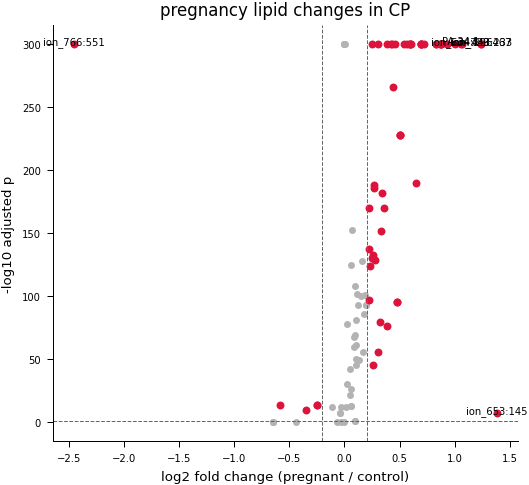

In [4]:
# the volcano: log2 fold change vs -log10 corrected p. label_col='lipid' annotates the
# strongest movers; the helper paints the grey/crimson points and the dashed thresholds.
plotting.volcano(diff, label_col="lipid", top_n=6,
                 title=f"pregnancy lipid changes in {region}")
plt.show()

That is the whole loop: a question, a subset, a test, a picture, a one-line biological
read. It took three cells. Your project is the same loop on a question you care about, run longer
and pushed harder.

❓ **QUESTION.** Before you move on, stress-test this result the way a reviewer would. We have
**exactly one control section and one pregnant section**. The Wilcoxon here compares pixels
*within* `CP`, not biological replicates. So the p-value answers can these two tissue slabs be
told apart, not is this difference reproducible across pregnant mice. What follow-up would start
to separate real biology from a two-section fluke? Hold that thought: it is the kind of what
could go wrong you must write into your own plan.

## look at your lipizones in space

One more habit before you plan. Your clustering gave every pixel a `lipizone` label, and a
labelling you cannot see is a labelling you cannot trust. So paint it. We colour the lipizones
with `plotting.lipizone_colors`, which orders the clusters by how similar their lipid centroids
are and then hands neighbours adjacent colours, so the map reads as a coherent anatomy rather
than random confetti. Never reach for a generic palette like `tab20` here: it scatters similar
territories across unrelated hues and hides the structure you worked to find.

🔬 **TASK.** Build the lipizone colours, store them, and draw both sections.

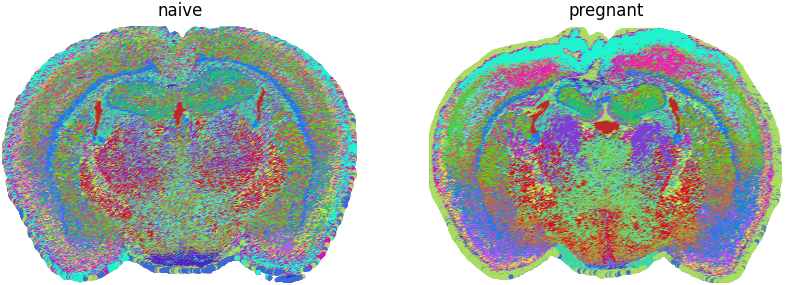

In [5]:
# assign each lipizone a colour (similar lipizones -> adjacent colours), store as a hex column
lz_colors = plotting.lipizone_colors(adata, key="lipizone", rep="X_nmf")
adata.obs["lipizone_color"] = adata.obs["lipizone"].astype(str).map(lz_colors)

# paint both sections by lipizone
plotting.spatial_categorical(adata, color_key="lipizone_color")
plt.show()

**check:** the two panels should show coherent, contiguous territories, not salt-and-pepper
noise: a clear cortical sheet, deep grey-matter blocks, and thin white-matter tracts, with the
same colours landing in the same places across the control and the pregnant section. That
cross-section agreement is the label transfer working. If it looks like confetti, your clustering
resolution is too high or the embedding is off, and that is worth fixing before you build on it.

## the planning template

Every good analysis starts on paper, not in code. Before you write a single line, fill in the six
boxes below. They are the same six a grant reviewer, a thesis committee, or your own future self
will ask about. Filling them honestly is half the work, and it is the half that stops you from
spending an afternoon computing something nobody asked for.

🔬 **TASK.** Copy the template in the next cell, then replace every `...` with your own words.
Keep it short. One or two sentences per box is plenty. Do this before you touch the data.

In [6]:
# ===========================  MY PROJECT PLAN  ===========================
#
# QUESTION
#   The one specific thing I want to know.
#   ...
#
# WHY IT MATTERS
#   What it would change about how we read the brain, the data, or the paper.
#   ...
#
# DATA
#   Exactly which pixels, lipids, regions, conditions, or external tables I will use,
#   and where they live (which adata.obs column? which lipid in var_names? the MERFISH
#   parquet?).
#   ...
#
# STRATEGY
#   The sequence of steps and which cl.<helper> performs each one.
#   ...
#
# WHAT RESULT WOULD ANSWER IT
#   The concrete number, figure, or comparison that says yes or no. Decide the
#   threshold NOW, before you see the answer, so you cannot move the goalposts.
#   ...
#
# WHAT COULD GO WRONG
#   Batch vs biology (we have only 2 sections), too few pixels, a confound, a
#   registration error, an annotation that is actually isobaric. Name the failure
#   mode you most fear, and how you would detect it.
#   ...
# =========================================================================
print("plan written. now, and only now, open the data.")

plan written. now, and only now, open the data.


💡 **HINT.** The hardest box is usually *what result would answer it*. If you cannot name
the figure or the number in advance, your question is still too vague. Narrow it until the answer
is a single plot you can imagine before you draw it.

## three starter directions

If you have your own question, skip these and go fill in the template. If you want a running
start, here are three concrete directions, each phrased as a prompt you could hand to Claude Code
or follow by hand. Pick one, make it yours, and write the plan for it.

### direction A: reproduce a claim from the paper

The biorxiv (Fusar Bassini et al., *The lipidomic architecture of the mouse brain*, 2025) makes
specific, checkable claims. One headline: in pregnancy, **myelination rises across white-matter
territories**, a broad adaptive remodeling read out as higher sphingolipid (`HexCer`, `Cer`, `SM`)
signal. The paper builds that claim on its full cohort (three pregnant and three control females)
with a Bayesian model. We have one section per condition and a simpler myelination score, so treat
the rise as a paper claim we have *not* yet verified here, and rebuild the check ourselves.

The trap to avoid: do not chase a single lipid and expect it to match. In your own annotation a
particular `HexCer` may even go the other way, while the *aggregate* sphingolipid signal still
rises. The robust quantity is the score across the class, not one ion. And to find the white
matter, select it by its Allen `acronym`: the tracts present in both sections include `cc` (corpus
callosum), `fi` (fimbria), `int` (internal capsule), `alv` (alveus), `ec` (external capsule),
`scwm`, `opt`, `st`, `fx`, and a few more. The worked cell below does exactly this check, read it,
then make it yours (a different region grouping, a spatial map alongside, a single sphingolipid
tested directly).

> *Prompt.* "Using `adata` and the `cajal_lipidomics` helpers, compute `analysis.myelination_score`
> for every pixel, then compare its mean between control and pregnant pixels, restricted to white
> matter. Build the white-matter mask from `adata.obs['acronym']` using tract acronyms like `cc`,
> `fi`, `int`, `alv`, `ec`, `scwm`. Compare that to grey matter as a control. Report whether the
> myelination score rises in pregnant white matter, and say whether the direction matches the
> paper's claim of broad pregnancy myelination."

What result would answer it: a higher mean myelination score in pregnant white matter than control,
ideally with grey matter staying flat, so the rise is specific to the tracts. The cell below runs
this so you can see the honest number before you extend it.

### direction B: test a hypothesis about one lipid class

Lipid classes have jobs. Sphingolipids (`HexCer`, `Cer`, `SM`) build myelin; the
glycerophospholipids (`PC`, `PE`, `PS`, `PG`, `PI`) build the bulk bilayer; lysolipids (`LPC`,
`LPE`) and `PA` are signalling and turnover intermediates. Form a hypothesis like *pregnancy shifts
the balance from structural sphingolipids toward turnover lysolipids* and test it.

> *Prompt.* "Parse every annotated name in `adata.var_names` into its lipid class with a regular
> expression (the class is the token before the first space, ignoring the `ion_` columns). Run
> `analysis.differential_lipids` on the whole section, then average the log2 fold change within each
> class and draw a bar chart of mean change per class with the count of lipids in each. Which classes
> go up, which go down, and is the sphingolipid-vs-lysolipid contrast real?"

What result would answer it: a ranked bar chart of per-class mean change, with the direction you
predicted either confirmed or refuted.

### direction C: explore a region you choose

We looked at `CP`. There are 174 Allen regions in these sections. Pick one you find interesting, the
piriform cortex `PIR`, a hippocampal field `CA3`, the lateral hypothalamus `LHA`, or scan
`adata.obs["acronym"].value_counts()` and choose by pixel count. Ask the same question we asked of
`CP`, or a different one: which lipizones live there, what lipids mark them, how the region changes
in pregnancy.

> *Prompt.* "Subset `adata` to Allen region `<your acronym>`, confirm it has at least ~150 pixels in
> both conditions, run `analysis.differential_lipids`, draw the volcano with `plotting.volcano`, and
> also show which of my lipizones compose the region with a value-count bar on `adata.obs['lipizone']`.
> Write two sentences on what the top changing named lipids suggest biologically."

What result would answer it: a volcano for your region plus its lipizone composition, and a short,
honest interpretation.

### or: bring your own data

If you arrived with your own MALDI, lipidomics, or spatial dataset, the best possible project is to
run this pipeline on it. The helpers assume an `AnnData` with pixels in rows, features in columns,
and metadata in `.obs`. If you can shape your data into that, almost every function above will work.
Talk to me early so we pick a tractable slice for the week.

🔬 **TASK.** Run direction A once, end to end, so the paper claim stops being a claim and
becomes a number you watched come out of code. We build a white-matter mask from Allen acronyms,
score myelination per pixel, and compare control to pregnant in the tracts against grey matter as a
control.

In [7]:
# direction A, worked: does the myelination signal rise in pregnant white matter?
# 1) score every pixel: mean z-scored sphingolipid (HexCer / Cer / SM) intensity
adata.obs["myelination"] = analysis.myelination_score(adata)

# 2) build a white-matter mask from Allen acronyms (the tracts present in both sections)
wm_acronyms = ["cc", "ccg", "fi", "int", "alv", "ec", "scwm", "or",
               "opt", "st", "fx", "em", "py", "arb", "fp", "df"]
wm = adata.obs["acronym"].astype(str).isin(wm_acronyms).values
gm = ~wm  # everything else, as a control: the rise should be specific to the tracts
print(f"white matter: {int(wm.sum())} pixels   grey matter: {int(gm.sum())} pixels")

# 3) compare the mean myelination score, control ('naive') vs pregnant, in each compartment
def mean_score(mask, cond):
    sel = mask & (adata.obs["Condition"] == cond).values
    return float(adata.obs["myelination"].values[sel].mean())

print("\nmyelination score (mean over pixels):")
print(f"  white matter : naive {mean_score(wm, 'naive'):+.3f}  ->  pregnant {mean_score(wm, 'pregnant'):+.3f}")
print(f"  grey matter  : naive {mean_score(gm, 'naive'):+.3f}  ->  pregnant {mean_score(gm, 'pregnant'):+.3f}")

white matter: 11147 pixels   grey matter: 177864 pixels

myelination score (mean over pixels):
  white matter : naive +0.272  ->  pregnant +0.418
  grey matter  : naive -0.009  ->  pregnant -0.034


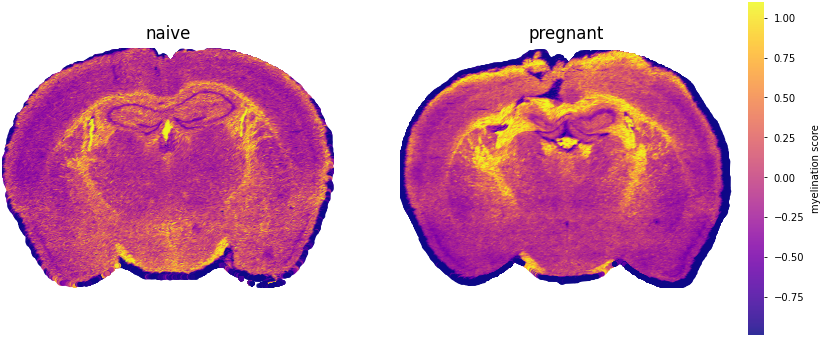

In [8]:
# the number is only half the answer; now look. paint the myelination score on both sections.
# we stash it as a temporary 'lipid' column so the spatial helper can map it on the shared scale.
adata.var_names = list(adata.var_names)  # plain list, so we can append a synthetic column safely
score_view = ad.AnnData(
    X=adata.obs["myelination"].values.reshape(-1, 1).astype("float32"),
    obs=adata.obs,
)
score_view.var_names = ["myelination score"]
plotting.spatial_lipid(score_view, "myelination score")
plt.show()

**check:** in your two sections the white-matter myelination score should come out **higher
in pregnant than control**, while grey matter stays roughly flat (or even dips a touch). That is the
*same direction* as the paper's claim of broad pregnancy myelination, reached from your own ions and
a far simpler score. The spatial map should show the tracts a touch brighter in the pregnant panel,
which is the picture behind the number. We have confirmed the *direction*, not the exact effect size:
one section per condition and a sum-of-sphingolipids score is not the paper's six-mouse Bayesian
model. This is the honest version of the claim, a verification path that runs with its limits stated
out loud. Now do the same for a claim of your own.

## using Claude Code well

You have an AI coding assistant for this project. Used well it is the best lab partner you will ever
have. Used badly it is a confident liar that wastes your afternoon. The difference is entirely in how
you supervise it. Four rules.

**Read what it writes, every line.** Never run code you do not understand. If the assistant produces
a block you cannot follow, ask it to explain that block before you run it, or ask it to rewrite it
more simply. The unrolled, transparent style of these notebooks exists so that you *can* read the
code. Keep that standard for the code the assistant gives you.

**Verify against reality, not against its confidence.** The assistant will state results in a sure
voice whether or not they are true. Check them. Did the cell actually run, or did it error and the
assistant move on? Does the pixel count match the check? Does the fold change have a plausible sign
and size? Print intermediate shapes and a few values. A number you have not seen printed by code that
ran is not a result, it is a guess.

**Iterate in small steps.** Ask for one cell at a time, run it, look at the output, then ask for the
next. A giant block that does everything at once is impossible to debug and easy to get subtly wrong.
Small steps with a printout after each are how you keep control.

**Give it the context it needs.** Tell it the data lives in `adata`, with `adata.X` as the
uMAIA-normalized intensities, `adata.var_names` named by lipid, your own labels in
`adata.obs['lipizone']`, and the `.obs` columns listed above. Point it at the helper source in
`src/cajal_lipidomics/`. Tell it we have exactly two sections and no biological replicates, so it
does not propose a replicate-level statistic we cannot run. The more precisely you frame the task,
the better the code.

❓ **QUESTION.** When the assistant hands you a result, what are the three quickest checks you can
run to catch a lie? (Mine: did the cell run without error, does a printed shape match what I expect,
and does the headline number have a sign and magnitude that make biological sense.)

## your turn

Below is a blank cell. Fill in your plan above first, then start your analysis here, one small step
at a time. Add as many cells as you need. Print as you go. Plot early and often: in this course, the
plots are the thinking, not the decoration.

🔬 **TASK.** Write your first analysis step.

In [9]:
# your analysis starts here
# (plan first, then one small step at a time, printing and plotting as you go)


## the presentation rubric

On the last day you present what you found, in a short talk plus one figure. You are not graded on
how much code you wrote or how fancy the method was. You are graded on whether you did honest
science. Aim for these five things.

1. **A clear question.** State it in one sentence at the top. We should know exactly what you set out
   to learn before you show us anything.
2. **The right picture.** One main figure that answers the question, made to the course style (clean
   axes, labelled, a colour scale with a unit). It should be readable from across the room and stand
   on its own.
3. **Honest numbers.** Every number you claim came from code that ran on the real data. No rounding
   away the inconvenient, no quoting a result you did not actually compute. Show the fold change, the
   count, the p-value as they came out.
4. **A biological reading.** Pair the result with what it means, in calibrated language. *Suggests*,
   *is consistent with*, *at a correlative level*, not *proves*. One good sentence of interpretation
   beats a paragraph of hedging.
5. **What could go wrong, named out loud.** Tell us the weakness you know about: the two-section
   limit, a small pixel count, a possible batch effect, an isobaric annotation. Owning the caveat is
   the strongest thing you can do. It is what separates a result from a claim.

💡 **HINT.** A two-minute talk that says *here is my one question, here is the one figure that
answers it, here is what it means, and here is what I am not sure about* will land far better than ten
rushed slides. Less, but solid.

## a last word

You started this course running code whose insides were hidden. You are ending it by choosing which
code to run, and why. That shift, from following a recipe to asking a question, is the whole point.
The lipid brain is enormous and barely mapped. Most of what is in these ions across nearly two
hundred thousand pixels has never been looked at carefully by anyone. Some of it is waiting for you.

Keep the habits this course tried to build: look at the data before you model it, unroll a method
until you understand it, pair every number with its meaning, and say plainly what you are unsure of.
Those habits outlast any one pipeline.

If you take this further, into your own data, your own thesis, a question that will not let you go, I
would genuinely like to hear about it. The atlas is a starting point, not a finish line, and the best
uses of it are the ones nobody has thought of yet.

Thank you for the week. Go find something.